# Storytelling with Data – Opowiadanie historii prawdziwymi danymi

Witaj na kolejnych zajęciach! Po opanowaniu biblioteki Seaborn i filozofii oszczędności formy (Data-Ink) przechodzimy do koncepcji z bestsellera **"Storytelling with Data"** (SWD) autorstwa Cole Nussbaumer Knaflic.

### Exploratory vs. Explanatory Analysis
Główna idea tej książki to przejście od **analizy eksploracyjnej** (Exploratory Analysis) do **analizy objaśniającej** (Explanatory Analysis).
- **Analiza eksploracyjna** to to, co robisz dla siebie: szukasz wzorców, rysujesz dziesiątki wykresów, sprawdzasz setki hipotez. Cole nazywa to *„szukaniem pereł w stu ostrygach”*.
- **Analiza objaśniająca** to to, co pokazujesz swojemu odbiorcy (szefowi, klientowi). Błędem jest pokazywanie im wszystkich 100 otwartych ostryg, by udowodnić, jak ciężko pracowałeś. Twoim zadaniem jest **pokazać im tylko te 2 perły**, które znalazłeś, i opowiedzieć o nich historię.

Dzisiaj wykonamy na prawdziwych danych 3 metamorfozy wykresów (make-overy) oraz 2 zadania dodatkowe, ucząc się:
- **Atrybutów przed-uwagowych (Pre-attentive attributes):** Używania koloru do natychmiastowego kierowania wzroku widza.
- **Usuwania szumu (Decluttering):** Eliminacji zbędnych elementów, które tworzą obciążenie poznawcze (*cognitive load*).

---

## 1. Przygotowanie i czyszczenie danych

Twoim pierwszym zadaniem jest wczytanie danych z [GitHuba](https://github.com/tadejow/warsztaty-wizualizacja-danych/tree/main/data) (`happiness_index.csv` oraz `world_data.csv`), wyczyszczenie ich i połączenie.

**Instrukcja krok po kroku (kod znajduje się w komórce poniżej):**
1. Importujemy niezbędne biblioteki: `pandas as pd`, `seaborn as sns`, `matplotlib.pyplot as plt`.
2. Wczytujemy pliki CSV z linków "Raw" używając funkcji `pd.read_csv()`.
3. Wybieramy tylko interesujące nas kolumny. W Pandas robimy to podając listę kolumn w podwójnych nawiasach kwadratowych, np.: `df_world[['country', 'Region']]`.
4. Łączymy obie tabele w jedną. Używamy do tego funkcji `pd.merge()`. Jako argumenty podajemy nazwy obu tabel, klucz po którym łączymy `on='country'` oraz typ łączenia `how='inner'` (zostawiamy tylko kraje występujące w obu tabelach).
5. Filtrujemy dane, aby zachować tylko roczniki 2014 i nowsze. Służy do tego maska logiczna: `df = df[df['year'] >= 2014]`.
6. Naprawiamy typ kolumny z wynikiem szczęścia (często wczytuje się jako tekst przez błędy w plikach CSV). Używamy `pd.to_numeric(df['life evaluation'], errors='coerce')`. Parametr `errors='coerce'` sprawi, że wszystkie niepoprawne znaki zamienią się na puste wartości `NaN`.
7. Usuwamy wiersze z pustymi wartościami (NaN) w kolumnie szczęścia używając metody `.dropna(subset=['life evaluation'], inplace=True)`. Argument `inplace=True` sprawia, że zmiana zapisuje się bezpośrednio w naszej tabeli.

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url_happiness = 'https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/happiness_index.csv'
url_world = 'https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/world_data.csv'
df_happiness = pd.read_csv(url_happiness)
df_world = pd.read_csv(url_world)[['country', 'Region']]
df = pd.merge(df_happiness, df_world, on='country', how='inner')
df = df[df['year'] >= 2014]
df['life evaluation'] = pd.to_numeric(df['life evaluation'], errors='coerce')
df.dropna(subset=['life evaluation'], inplace=True)

print(df.shape) #Dane gotowe! Mamy 1308 wierszy.


(1308, 19)


## 2. Make-over: Kierowanie uwagi kolorem (Focus attention)
*(Inspiracja: SWD, Rozdział 4 "Focus your audience's attention")*

Kolor powinien być używany celowo i strategicznie. Jeśli chcesz pokazać pozycję Polski na tle innych państw, użycie domyślnej "tęczy" sprawi, że żaden słupek się nie wyróżni. Mózg zignoruje kolory jako zwykłą ozdobę.

**Instrukcja krok po kroku:**
1. **Filtrowanie i sortowanie danych:**
   - Stwórz listę `kraje =['Finland', 'Denmark', 'Germany', 'United Kingdom', 'France', 'Poland', 'Czech Republic', 'Spain', 'Italy', 'Ukraine']`.
   - Wyfiltruj tabelę używając wielu warunków naraz (każdy warunek w okrągłych nawiasach połączony operatorem `&`): `df[(df['year'] == 2024) & (df['country'].isin(kraje))]`. Zapisz to jako nową zmienną `df_eur`. Zastosuj metodę `.copy()` na końcu.
   - Posortuj tabelę malejąco. Użyj metody `df_eur.sort_values(by='life evaluation', ascending=False)`. Zresetuj indeksy dodając na końcu `.reset_index(drop=True)`.
2. Utwórz układ dwóch wykresów obok siebie: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))`.
3. Na lewym subplocie (`ax1`) narysuj poziomy wykres słupkowy. Użyj `sns.barplot(data=df_eur, y='country', x='life evaluation', hue='country', palette='Set3', ax=ax1)`. Wyłącz legendę argumentem `legend=False`. Dodaj tytuł.
4. **Magia Storytellingu (przygotowanie kolorów):** Stwórz listę o nazwie `kolory`. Użyjemy w tym celu pętli zapisanej w jednej linii (tzw. *list comprehension*). Przejdź pętlą `for c in df_eur['country']` i powiedz Pythonowi: jeśli nazwa kraju to `'Poland'`, wstaw kolor `'steelblue'`, w przeciwnym razie `'lightgray'`.
5. Na prawym subplocie (`ax2`) narysuj ten sam wykres `sns.barplot(...)`, ale do argumentu `palette` przypisz swoją nową listę `kolory`.
6. **Usuwanie szumu (Decluttering):** Użyj pętli `for spine in ['top', 'right', 'bottom']:`, aby ukryć 3 krawędzie osi wywołując `ax2.spines[spine].set_visible(False)`.
7. Wyłącz liczniki (tzw. ticki) na osi X: `ax2.tick_params(bottom=False, labelbottom=False)`. Usuń tekst osi używając `ax2.set_xlabel('')`.
8. **Bezpośrednie etykiety (Direct Labeling):** Zamiast osi z liczbami, wstawimy wartości bezpośrednio za słupkami!
   - Użyj pętli `for index, row in df_eur.iterrows():`.
   - Zmienna `row['life evaluation']` przechowuje wynik.
   - Użyj `ax2.text()`. Jako współrzędną X podaj wynik plus mały margines (np. `val + 0.1`). Jako Y podaj `index`. Jako wyświetlany tekst podaj sformatowaną liczbę `f'{val:.2f}'`.
   - Wewnątrz pętli stwórz zmienne, które ustawią parametr `fontweight='bold'` oraz `color='steelblue'`, ale *tylko* jeśli `row['country'] == 'Poland'`. Przekaż te parametry do funkcji `text()`.

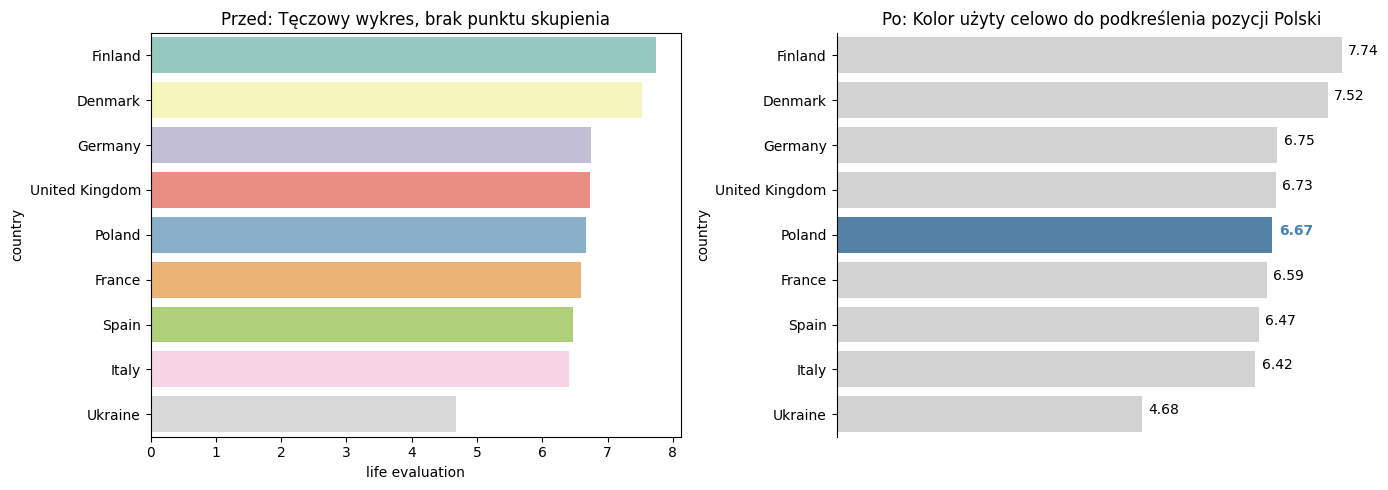

In [41]:
kraje = ['Finland', 'Denmark', 'Germany', 'United Kingdom', 'France', 'Poland', 'Czech Republic', 'Spain', 'Italy', 'Ukraine']
df_eur = df[(df['year'] == 2024) & (df['country'].isin(kraje))].copy()
df_eur = df_eur.sort_values(by='life evaluation', ascending=False).reset_index(drop=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_eur, y='country', x='life evaluation', hue='country', palette='Set3', ax=ax1, legend=False)
ax1.set_title('Przed: Tęczowy wykres, brak punktu skupienia')

kolory = ['steelblue' if c == 'Poland' else 'lightgray' for c in df_eur['country']]
sns.barplot(data=df_eur, y='country', x='life evaluation', hue='country', palette=kolory, ax=ax2, legend=False)
ax2.set_title('Po: Kolor użyty celowo do podkreślenia pozycji Polski')

for spine in ['top', 'right', 'bottom']:
    ax2.spines[spine].set_visible(False)

ax2.tick_params(bottom=False, labelbottom=False)
ax2.set_xlabel('')

for index, row in df_eur.iterrows():
    val = row['life evaluation']
    if row['country'] == 'Poland':
        ax2.text(val + 0.1, index, f'{val:.2f}',fontweight='bold', color='steelblue')
    else:
        ax2.text(val + 0.1, index, f'{val:.2f}')
plt.tight_layout()
plt.show()

## 3. Make-over: Od Spaghetti Graph do czytelnego trendu
*(Inspiracja: SWD, Rozdział 9 "Strategies for avoiding the spaghetti graph")*

Wykresy "spaghetti" powstają, gdy na jednym wykresie liniowym rysujemy kilkanaście linii w różnych kolorach. Zaczynają się one przecinać i stają się absolutnie nieczytelne.
Rozwiązanie? Wrzuć wszystkie linie w tło (jako cienkie, szare linie), a mocnym kolorem narysuj tylko te, które są głównymi bohaterami Twojej historii. Pamiętaj jednak, że w szeregach czasowych **nie usuwamy osi X**, ponieważ lata budują niezbędny kontekst!

**Instrukcja krok po kroku:**
1. Zbudujmy koszyk państw: `kraje_spag =['Poland', 'Ukraine', 'Germany', 'France', 'Spain', 'Italy', 'Romania', 'Hungary']`. Odfiltruj tabelę, używając metody `.isin(kraje_spag)` i posortuj chronologicznie używając `sort_values(by='year')`. Zapisz jako `df_spag`.
2. Na lewym subplocie (`ax1`) wygeneruj klasyczne spaghetti używając `sns.lineplot(data=df_spag, x='year', y='life evaluation', hue='country', ax=ax1, palette='tab10')`.
3. Na prawym subplocie (`ax2`) wyczyść tylko górną i prawą ramkę osi używając `ax2.spines['...'].set_visible(False)`. Zostawiamy dół!
4. **Wygaszanie tła:** Będziemy rysować linie ręcznie. Stwórz pętlę `for kraj in kraje_spag:`, aby przejść przez państwa po kolei. Wewnątrz pętli odfiltruj dane tylko dla bieżącego państwa: `df_kraj = df_spag[df_spag['country'] == kraj]`.
5. Wewnątrz pętli stwórz instrukcję warunkową `if/elif/else`:
   - Jeśli to `'Poland'`, ustaw grubość linii `grubosc=3` oraz kolor `'steelblue'`.
   - Jeśli to `'Ukraine'`, ustaw grubość `grubosc=3` oraz kolor `'indianred'`.
   - Dla reszty państw (sekcja `else`) ustaw grubość `1.5` i kolor `'lightgray'`.
6. Ciągle będąc w pętli, użyj domyślnego rysowania Matplotlib: `ax2.plot(df_kraj['year'], df_kraj['life evaluation'], color=kolor, linewidth=grubosc)`.
7. **Direct Labeling dla głównych linii:** Chcemy podpisać Polskę i Ukrainę dokładnie na końcu ich linii. Używamy do tego `ax2.text()`. Aby zdobyć współrzędne końca linii, użyj metody `.iloc[-1]` (która zwraca absolutnie ostatnią wartość w kolumnie DataFrame). Czyli współrzędna X to `df_kraj['year'].iloc[-1] + 0.2`, a Y to `df_kraj['life evaluation'].iloc[-1]`. Zrób to w blokach `if` i `elif`!
8. Poza pętlą wymuś zmianę limitów osi X za pomocą `ax2.set_xlim(2011, 2026)`, aby zrobić miejsce na tekst z prawej strony.

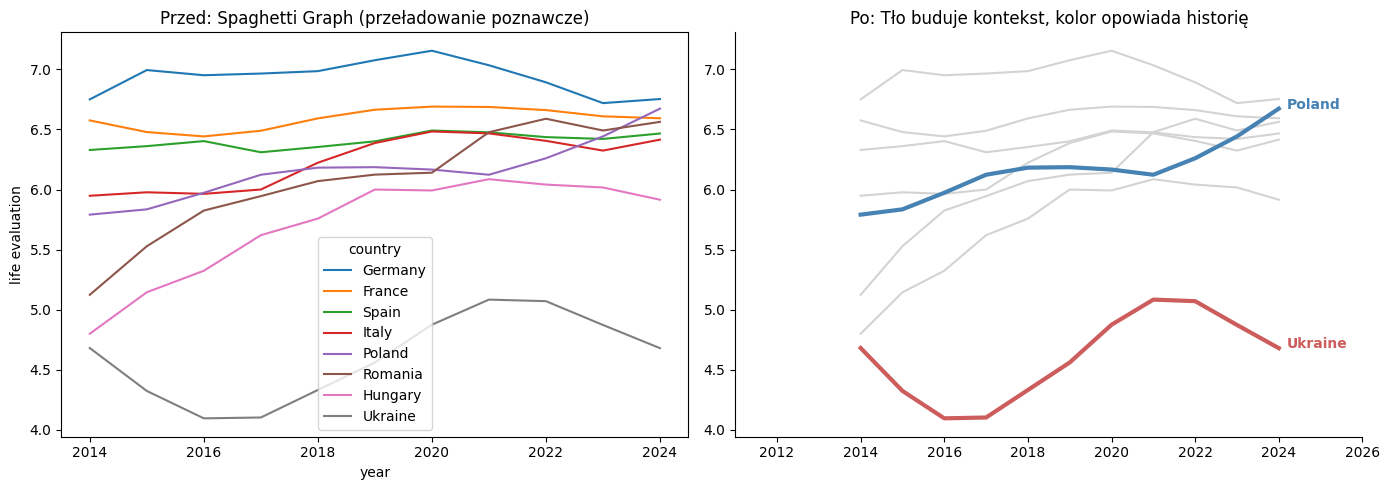

In [42]:
kraje_spage = ['Poland', 'Ukraine', 'Germany', 'France', 'Spain', 'Italy', 'Romania', 'Hungary']
df_spag = df[df['country'].isin(kraje_spage)].sort_values(by='year')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(data=df_spag, x='year', y='life evaluation', hue='country', ax=ax1, palette='tab10')
ax1.set_title('Przed: Spaghetti Graph (przeładowanie poznawcze)')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Po: Tło buduje kontekst, kolor opowiada historię')

for kraj in kraje_spage:
    df_kraj = df_spag[df_spag['country'] == kraj]
    if kraj == 'Poland':
        grubosc = 3
        kolor = 'steelblue'
        ax2.plot(df_kraj['year'], df_kraj['life evaluation'], color=kolor, linewidth=grubosc)
        ax2.text(df_kraj['year'].iloc[-1] + 0.2, df_kraj['life evaluation'].iloc[-1], 'Poland', color=kolor, fontweight='bold', zorder=4)
    elif kraj == 'Ukraine':
        grubosc = 3
        kolor = 'indianred'
        ax2.plot(df_kraj['year'], df_kraj['life evaluation'], color=kolor, linewidth=grubosc)
        ax2.text(df_kraj['year'].iloc[-1] + 0.2, df_kraj['life evaluation'].iloc[-1], 'Ukraine', color=kolor, fontweight='bold')
    else:
        grubosc = 1.5
        kolor = 'lightgray'
        ax2.plot(df_kraj['year'], df_kraj['life evaluation'], color=kolor, linewidth=grubosc, zorder=1)

ax2.set_xlim(2011, 2026)
plt.tight_layout()
plt.show()

## 4. Make-over: Slopegraph zamiast zgrupowanych słupków
*(Inspiracja: SWD, Rozdział 2, str. 47-49)*

Aby porównać spadek lub wzrost zmiennej między dwoma momentami w czasie dla kliku kategorii, programy domyślnie tworzą pogrupowane wykresy słupkowe. Zmusza to widza do skakania wzrokiem.
Cole proponuje **Slopegraph** (wykres nachylenia). Zostają tylko dwa punkty na osi czasu połączone linią. Kąt nachylenia natychmiast komunikuje kierunek i siłę zmiany!
Zachowamy tutaj **spójność kolorystyczną** z poprzednim wykresem: naszą narrację oprzemy na Polsce i Ukrainie, a resztę państw zepchniemy do tła.

**Instrukcja krok po kroku:**
1. Stwórz zestaw: `kraje_slope =['Poland', 'Ukraine', 'Germany', 'Spain', 'Romania']`. Odfiltruj ramkę tylko dla tych krajów i użyj warunku `.isin([2014, 2024])` w kolumnie `year`. Zapisz jako `df_slope`.
2. Zrób tabelę przestawną. Przekształci ona nasze dane tak, że w wierszach będą kraje, a w kolumnach lata. Służy do tego funkcja: `df_pivot = df_slope.pivot(index='country', columns='year', values='life evaluation')`.
3. Na lewym subplocie narysuj klasyczny `sns.barplot()`. Aby zgrupować słupki, użyj `x='country'`, `y='life evaluation'`, a jako grupowanie dodaj `hue='year'`.
4. Na prawym subplocie (`ax2`) wyłącz całkowicie wszystko: ramki, liczby, siatki, wywołując po prostu `ax2.axis('off')`.
5. Rysujemy Slopegraph! Użyj pętli, by przejść przez wiersze w tabeli przestawnej: `for kraj, row in df_pivot.iterrows():`.
6. Wewnątrz pętli wyciągnij dwie wartości: `v14 = row[2014]` oraz `v24 = row[2024]`.
7. Odtwórz mechanizm z poprzedniego zadania: instrukcją `if` nadaj Polsce mocny niebieski kolor (`'steelblue'`), Ukrainie czerwony (`'indianred'`), a reszcie szary (`'lightgray'`). Dopasuj odpowiednio grubości linii i tzw. `zorder` (aby kolory nakładały się na szare, ustaw ich `zorder` na wyższy np. `4`).
8. Narysuj linię łączącą punkt początkowy (na osi X przyjmiemy wartość `0`) i końcowy (na osi X to będzie `1`). Służy do tego funkcja: `ax2.plot([0, 1], [v14, v24], marker='o', color=kolor, lw=grubosc)`.
9. Po lewej i prawej stronie punktów dopisz nazwy państw i dokładne wartości używając `ax2.text()`. Użyj atrybutu `ha='right'` (wyrównanie do prawej) dla tekstu z lewej strony oraz `ha='left'` dla prawej.
10. Poza pętlą, sztywno ustaw limity osi X od `-0.5` do `1.5`, aby wycentrować wykres, i napisz ręcznie daty "2014" oraz "2024" nad wykresem wywołując `ax2.text()`.

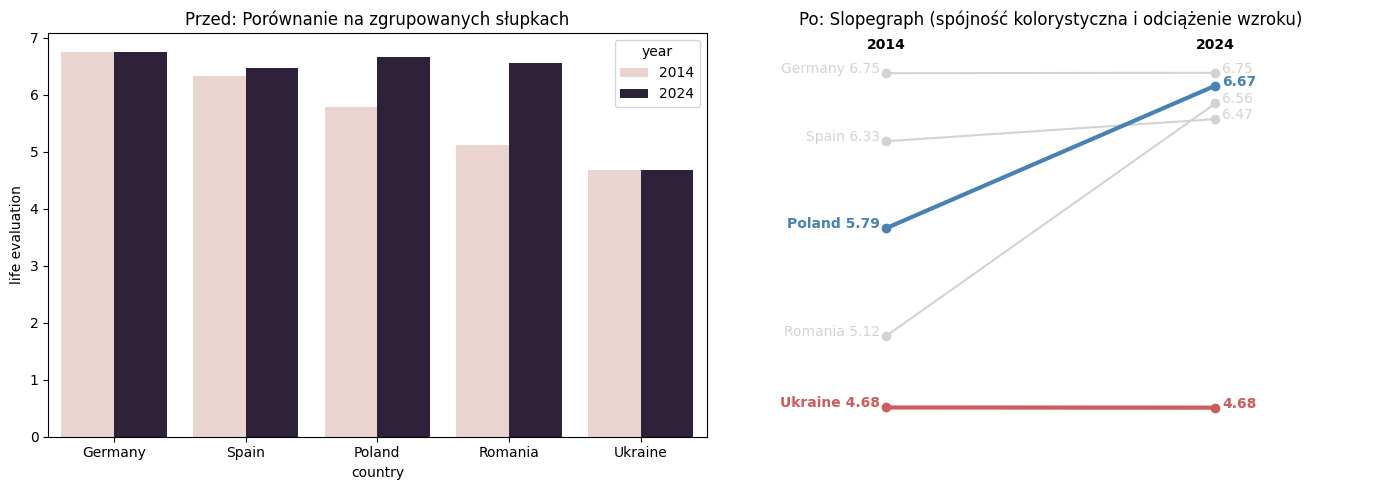

In [43]:
kraje_slope = ['Poland', 'Ukraine', 'Germany', 'Spain', 'Romania']
df_slope = df[(df['country'].isin(kraje_slope)) & (df['year'].isin([2014, 2024]))]
df_pivot = df_slope.pivot(index='country', columns='year', values='life evaluation')
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=df_slope, x='country', y='life evaluation', hue='year', ax=ax1)
ax2.axis('off')
for kraj, row in df_pivot.iterrows():
    v14 = row[2014]
    v24 = row[2024]
    if kraj == 'Poland':
        kolor = 'steelblue'
        grubosc = 3
        zorder_val = 4
        ax2.plot([0, 1], [v14, v24], marker='o', color=kolor, lw=grubosc, zorder=zorder_val)
        ax2.text(-0.02, v14, f'{kraj} {v14:.2f}', ha='right', color=kolor, fontweight='bold', zorder=zorder_val)
        ax2.text(1.02, v24, f'{v24:.2f}', ha='left', color=kolor, fontweight='bold', zorder=zorder_val)
    elif kraj == 'Ukraine':
        kolor = 'indianred'
        grubosc = 3
        zorder_val = 4
        ax2.plot([0, 1], [v14, v24], marker='o', color=kolor, lw=grubosc, zorder=zorder_val)
        ax2.text(-0.02, v14, f'{kraj} {v14:.2f}', ha='right', color=kolor, fontweight='bold', zorder=zorder_val)
        ax2.text(1.02, v24, f'{v24:.2f}', ha='left', color=kolor, fontweight='bold', zorder=zorder_val)
    else:
        kolor = 'lightgray'
        grubosc = 1.5
        zorder_val = 1
        ax2.plot([0, 1], [v14, v24], marker='o', color=kolor, lw=grubosc, zorder=zorder_val)
        ax2.text(-0.02, v14, f'{kraj} {v14:.2f}', ha='right', color=kolor, zorder=zorder_val)
        ax2.text(1.02, v24, f'{v24:.2f}', ha='left', color=kolor, zorder=zorder_val)

ax1.set_title('Przed: Porównanie na zgrupowanych słupkach')
ax2.set_title('Po: Slopegraph (spójność kolorystyczna i odciążenie wzroku)')
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(4.5, 7.0)
ax2.text(0, ax2.get_ylim()[1] - 0.1, '2014', ha='center', fontweight='bold')
ax2.text(1, ax2.get_ylim()[1] - 0.1, '2024', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Zadania dodatkowe dla chętnych (Power User)

Gdy perfekcyjnie opanujesz usuwanie szumu, możesz zacząć stosować zaawansowane układy oparte na rzeczywistych analizach biznesowych. Oba poniższe zadania wykorzystają wczytane przez nas dane o szczęściu.

### A. Wykres Odchyleń (Diverging Bar Chart)
Często analitycy nie pokazują suchych liczb, ale odchylenie od jakiejś normy (np. średniej europejskiej).
**Instrukcja:**
1. Wyfiltruj `df` tylko dla `Region == 'EUROPE & NORTHERN AMERICA'` i `year == 2024`. Posortuj malejąco po poczuciu szczęścia i wybierz pierwsze 15 państw (użyj metody `.head(15)`). Zapisz jako `df_dev`.
2. Oblicz średnią dla tej wyselekcjonowanej 15-tki: `mean_val = df_dev['life evaluation'].mean()`.
3. Stwórz nową kolumnę `'diff'` w swojej tabeli: `df_dev['diff'] = df_dev['life evaluation'] - mean_val`.
4. Przesortuj ponownie tabelę `df_dev`, tym razem po nowej kolumnie `'diff'`, od największego do najmniejszego (pamiętaj o `ascending=False` oraz `.reset_index(drop=True)`).
5. Zdefiniuj listę kolorów (tzw. list comprehension): wpisz do listy kolor `'mediumseagreen'` (zielony), jeśli wartość z kolumny `'diff'` w wierszu jest $> 0$, w przeciwnym razie wpisz `'indianred'` (czerwony).
6. Narysuj poziomy wykres słupkowy `sns.barplot(data=df_dev, x='diff', y='country')`. Zastosuj Twoją listę kolorów używając parametru `palette=`.
7. Oczyść wykres z ramek. Zastosuj Tufte'owski trik: dodaj wyraźną, grubą czarną linię bazową przelatującą idealnie przez zero na osi X! Służy do tego metoda: `ax.axvline(x=0, color='black', linewidth=2)`.

### B. Małe Wielokrotności dla Trendów (Small Multiples)
*(Inspiracja: SWD, Rozdział 9 - Panel charts)*
Kiedy na jednym wykresie gnieździ się za dużo obiektów dla różnych kategorii, kolory i kształty zlewają się w plamę. Rozwiązaniem jest technika *Small Multiples* – rozbicie analizy na matrycę mniejszych wykresików. Wszystkie wykresiki muszą koniecznie dzielić identyczną skalę na osiach!
W bibliotece Seaborn robi się to bardzo prosto przy użyciu funkcji tzw. poziomu figury (Figure-level), np. `sns.relplot()`.
**Instrukcja:**
1. Zdefiniuj nową listę państw z różnych rejonów świata: `kraje_sm = ['Poland', 'Germany', 'Ukraine', 'United States', 'Japan', 'Brazil']`.
2. Odfiltruj główną ramkę `df` tylko do tych państw.
3. Zamiast `plt.subplots`, użyjemy specjalnej funkcji w Seabornie do robienia całych siatek. Stwórz zmienną, przypisując do niej wykres: `g = sns.relplot()`.
4. Przekaż do niej odpowiednie parametry, zupełnie jak dla zwykłego lineplota: `data=df_sm`, `x='year'`, `y='life evaluation'`, `kind='line'`.
5. Magia matrycy działa dzięki parametrom: dodaj `col='country'` (dzięki temu Seaborn potnie ramkę i stworzy niezależny wykres dla każdego kraju ze spójną osią X i Y!) oraz `col_wrap=3` (ta funkcja przełamuje rysowanie do nowego wiersza po narysowaniu 3 wykresów obok siebie).
6. Aby linie były w różnych kolorach, dodaj `hue='country'` oraz wyłącz domyślną dużą legendę `legend=False`.

/tmp/ipykernel_2259/3736987715.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dev, x='diff', y='country', palette=kolory, ax=ax)


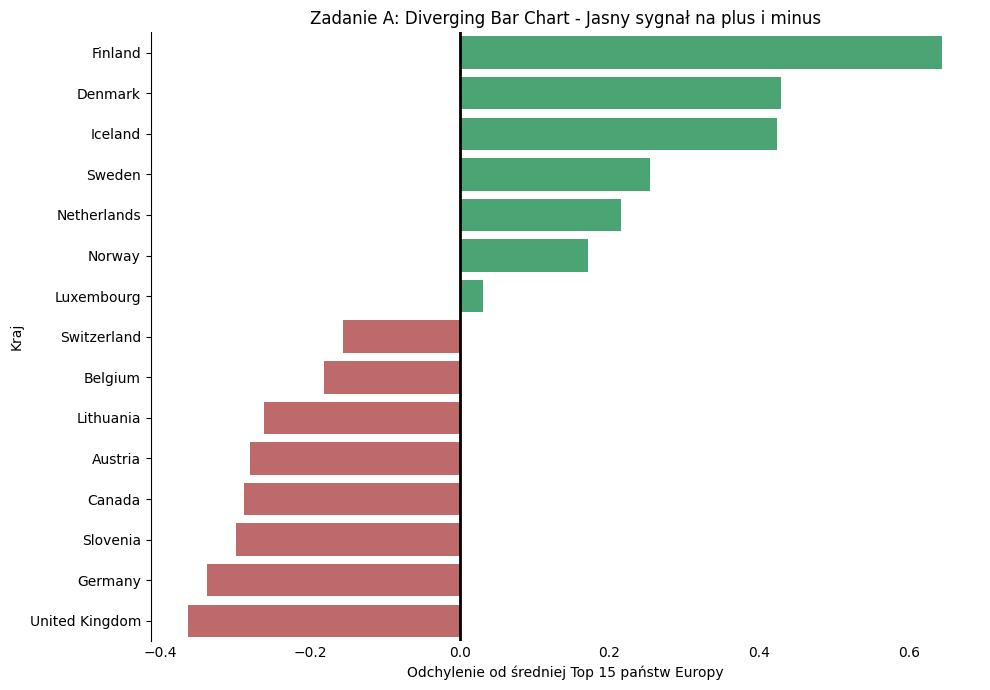

In [44]:
df_dev = df[(df['Region']=='EUROPE & NORTHERN AMERICA') & (df['year']==2024)].sort_values(by='life evaluation', ascending=False).head(15).reset_index()
mean_val = df_dev['life evaluation'].mean()
df_dev['diff'] = df_dev['life evaluation'] - mean_val
df_dev = df_dev.sort_values(by='diff', ascending=False).reset_index(drop=True)
kolory = ['mediumseagreen' if val > 0 else 'indianred' for val in df_dev['diff']]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=df_dev, x='diff', y='country', palette=kolory, ax=ax)
ax.set_title('Zadanie A: Diverging Bar Chart - Jasny sygnał na plus i minus')
ax.set_xlabel('Odchylenie od średniej Top 15 państw Europy')
ax.set_ylabel('Kraj')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', length=0)

ax.axvline(x=0, color='black', linewidth=2)

plt.tight_layout()
plt.show()

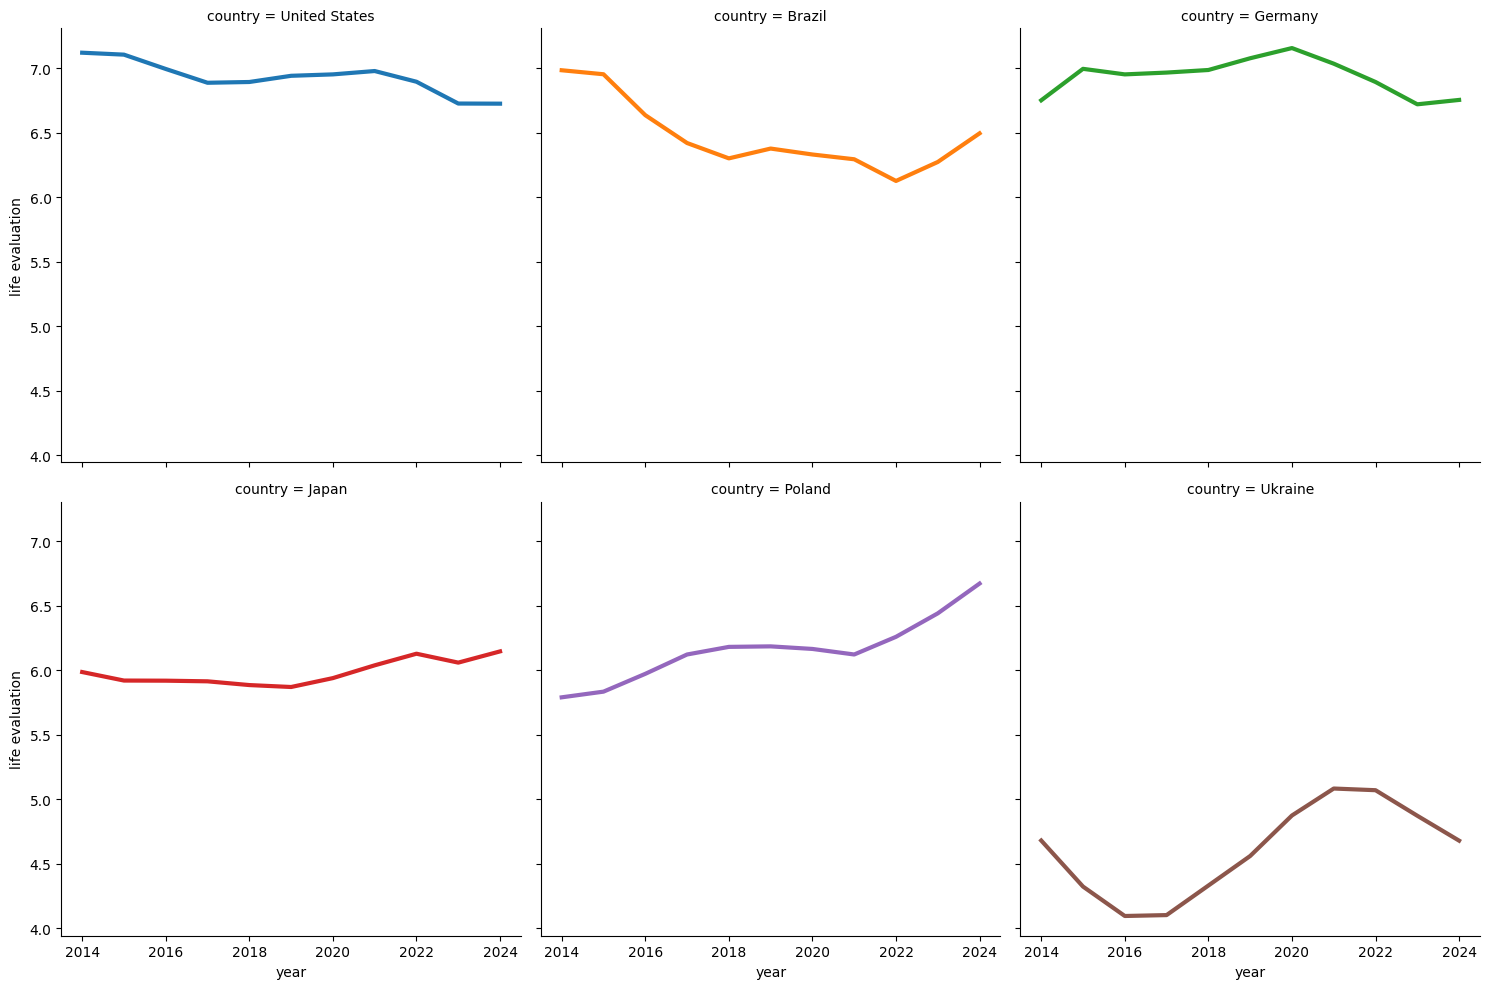

In [45]:
kraje_sm = ['Poland', 'Germany', 'Ukraine', 'United States', 'Japan', 'Brazil']
df_sm = df[df['country'].isin(kraje_sm)]
g = sns.relplot(data=df_sm, x='year', y='life evaluation', kind='line', col='country', linewidth=3, col_wrap=3, hue='country', legend=False)
plt.tight_layout()
plt.show()

## Podsumowanie - Take home message

> *"There is a story in your data. But your tools don't know what that story is. That's where it takes you — the analyst or communicator of the information — to bring that story visually and contextually to life."*
>
> **~ Cole Nussbaumer Knaflic, Storytelling with Data**

Kiedy klikasz "wstaw wykres" w Excelu, Pythonie, Tableau czy PowerBI – narzędzie wykonuje ślepe polecenie graficzne. To w Twoich rękach (analityka/naukowca) leży wyczyszczenie tego ze zbędnego szumu i wskazanie odbiorcy palcem (poprzez pogrubienie, dodanie adnotacji i użycie agresywnego koloru) gdzie dokładnie jest **ta jedna rzecz, na którą powinien zwrócić uwagę**.